In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.decomposition import PCA

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb

import shap

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE, SVMSMOTE, KMeansSMOTE
from imblearn.under_sampling import EditedNearestNeighbours

import optuna
import warnings

/home/joanna/miniforge3/envs/hw2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parameters

In [2]:
# parameters
output_name = 'result/out_0415_43.csv'

TOP_K_FEATURES = 40
tuning_xgb = False
tuning_lgbm = False
tuning_catboost = False

## Read the files

In [3]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
print("Training data shape: ", train_df.shape)
print("Testing data shape: ", test_df.shape)
print(train_df.head())

Training data shape:  (5543, 96)
Testing data shape:  (1386, 95)
        f01       f02       f03       f04  f05       f06           f07  \
0  0.698674  0.061215  0.375422  0.456570  1.0  0.551445  3.449435e+07   
1  0.585954  0.019678  0.368082  0.454630  1.0  0.552263  3.449435e+07   
2  0.393947  0.043159  0.372162  0.454800  1.0  0.547441  3.449435e+07   
3  0.707323  0.055729  0.370605       NaN  1.0  0.551575  3.449435e+07   
4  0.791703       NaN  0.367408  0.454629  1.0  0.551976  3.449435e+07   

        f08           f09       f10  ...       f87       f88           f89  \
0  0.014768  4.072437e+07  0.816031  ...  0.260336  0.041482 -2.928195e+07   
1 -0.000589  4.072437e+07       NaN  ...  0.255530       NaN -2.928195e+07   
2  0.009169  4.072437e+07  0.816244  ...  0.256560  0.039615 -2.928195e+07   
3       NaN  4.072437e+07  0.816036  ...  0.257378  0.039626 -2.928195e+07   
4  0.040703  4.072437e+07  0.816062  ...  0.255496  0.039525 -2.928195e+07   

        f90          

In [4]:
sns.set_theme(style="whitegrid")

print("--- Target Variable Distribution (Bankrupt) ---")
target_counts = train_df['Bankrupt'].value_counts()
print(target_counts)

bankruptcy_rate = (target_counts.get(1, 0) / len(train_df)) * 100
print(f"Bankruptcy Rate: {bankruptcy_rate:.2f}%\n")

# Plot target distribution to visualize class imbalance
# plt.figure(figsize=(6, 4))
# sns.countplot(data=train_df, x='Bankrupt', palette='Set2')
# plt.title('Distribution of Target Variable (Bankrupt)')
# plt.xlabel('Bankrupt (0: No, 1: Yes)')
# plt.ylabel('Count')
# plt.show()

print("\n--- Statistical Summary ---")
display(train_df.describe())

--- Target Variable Distribution (Bankrupt) ---
Bankrupt
0    5279
1     264
Name: count, dtype: int64
Bankruptcy Rate: 4.76%


--- Statistical Summary ---


,f01,f02,f03,f04,f05,f06,f07,f08,f09,f10,...,f87,f88,f89,f90,f91,f92,f93,f94,f95,Bankrupt
count,4954.000000,4948.000000,4989.000000,5002.000000,5039.0,4991.000000,4.985000e+03,4974.000000,5.016000e+03,4960.000000,...,4963.000000,5012.000000,4.979000e+03,4976.000000,4.995000e+03,4966.000000,4972.000000,5001.000000,4995.000000,5543.000000
mean,0.613858,0.045764,0.373606,0.454846,1.0,0.551799,4.491276e+07,0.029805,4.474782e+07,0.815856,...,0.258556,0.040434,-2.757054e+07,0.274628,2.150021e+09,0.418786,0.114638,0.996089,0.021310,0.047628
std,0.165476,0.035715,0.017842,0.007853,0.0,0.007872,2.409993e+08,0.030215,1.648237e+08,0.011103,...,0.009082,0.015500,1.065916e+08,0.009296,3.972556e+09,0.021856,0.081273,0.014283,0.002273,0.212996
min,0.006730,0.005420,0.178709,-0.000428,1.0,0.362495,3.449435e+07,-0.006988,4.072437e+07,0.083457,...,0.120517,0.004056,-2.928195e+07,0.128896,-2.818454e+08,0.003122,0.000062,-0.002503,-0.000292,0.000000
25%,0.507402,0.028520,0.368716,0.454605,1.0,0.551475,3.449435e+07,0.011498,4.072437e+07,0.816013,...,0.255777,0.039516,-2.928195e+07,0.271739,-2.818454e+08,0.413410,0.062217,0.996205,0.021136,0.000000
50%,0.650324,0.041107,0.371207,0.454666,1.0,0.551685,3.449435e+07,0.021785,4.072437e+07,0.816077,...,0.257051,0.039539,-2.928195e+07,0.273043,-2.818454e+08,0.419742,0.096341,0.996278,0.021174,0.000000
75%,0.757922,0.055072,0.374904,0.454973,1.0,0.551937,3.449435e+07,0.038213,4.072437e+07,0.816169,...,0.259185,0.039680,-2.928195e+07,0.275308,4.776173e+09,0.426529,0.143872,0.996370,0.021224,0.000000
max,0.804905,1.286272,0.988904,0.647391,1.0,0.882367,7.890958e+09,0.263248,7.306120e+09,1.008685,...,0.603252,0.719665,7.414732e+09,0.638637,1.201246e+10,0.835771,0.812952,1.042988,0.098428,1.000000


## Split train data

In [6]:
# 1. Define features (X) and target (y)
# Exclude 'Bankrupt' (target) and 'Id' (identifier) from features
drop_cols = ['Bankrupt']
if 'Id' in train_df.columns:
    drop_cols.append('Id')

X = train_df.drop(columns=drop_cols)
y = train_df['Bankrupt']
y = y.values.reshape(-1, 1)

print("X shape: ", X.shape)
print("y shape: ", y.shape)


X shape:  (5543, 95)
y shape:  (5543, 1)


In [7]:
# 2. Split the data into Training (80%) and Validation (20%) sets
# IMPORTANT: Use 'stratify=y' to maintain the minority class proportion in both sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 3. Output the dimensions of the resulting splits
print("--- Data Split Summary ---")
print(f"Total dataset: {X.shape[0]} rows")
print(f"Training set (80%): X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Validation set (20%): X_val {X_val.shape}, y_val {y_val.shape}\n")

# 4. Verify stratification (Bankruptcy rate should be identical across splits)
print("--- Stratification Check (Bankruptcy Rate) ---")
original_rate = (y.sum() / len(y)) * 100
train_rate = (y_train.sum() / len(y_train)) * 100
val_rate = (y_val.sum() / len(y_val)) * 100

print(f"Original Dataset Bankruptcy Rate:   {original_rate:.2f}%")
print(f"Training Set Bankruptcy Rate:       {train_rate:.2f}%")
print(f"Validation Set Bankruptcy Rate:     {val_rate:.2f}%")

--- Data Split Summary ---
Total dataset: 5543 rows
Training set (80%): X_train (4434, 95), y_train (4434, 1)
Validation set (20%): X_val (1109, 95), y_val (1109, 1)

--- Stratification Check (Bankruptcy Rate) ---
Original Dataset Bankruptcy Rate:   4.76%
Training Set Bankruptcy Rate:       4.76%
Validation Set Bankruptcy Rate:     4.78%


## Advanced missing value imutation

In [8]:
print("--- Advanced Missing Value Imputation (Iterative Imputer) ---")

est = BayesianRidge()
imputer = IterativeImputer(
    estimator=est,
    missing_values=np.nan,
    max_iter=10,
    random_state=42,
    verbose=2
)

print("Fitting imputer on X_train and transforming data...")
X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)

X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_val = pd.DataFrame(X_val_imputed, columns=X_val.columns, index=X_val.index)

print("\n--- Imputation Verification ---")
print(f"Missing values remaining in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing values remaining in X_val:   {X_val.isnull().sum().sum()}")

display(X_train.head())

--- Advanced Missing Value Imputation (Iterative Imputer) ---
Fitting imputer on X_train and transforming data...
[IterativeImputer] Completing matrix with shape (4434, 95)
[IterativeImputer] Ending imputation round 1/10, elapsed time 2.26
[IterativeImputer] Change: 8692522032.827745, scaled tolerance: 14377399.341736453 
[IterativeImputer] Ending imputation round 2/10, elapsed time 4.27
[IterativeImputer] Change: 1350630865.3914921, scaled tolerance: 14377399.341736453 
[IterativeImputer] Ending imputation round 3/10, elapsed time 6.25
[IterativeImputer] Change: 357490664.5752356, scaled tolerance: 14377399.341736453 
[IterativeImputer] Ending imputation round 4/10, elapsed time 8.25
[IterativeImputer] Change: 72782106.691536, scaled tolerance: 14377399.341736453 
[IterativeImputer] Ending imputation round 5/10, elapsed time 10.35
[IterativeImputer] Change: 14338351.038054327, scaled tolerance: 14377399.341736453 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer]

,f01,f02,f03,f04,f05,f06,f07,f08,f09,f10,...,f86,f87,f88,f89,f90,f91,f92,f93,f94,f95
2369,0.252694,0.015710,0.372004,0.455709,1.0,0.552145,3.449435e+07,0.053438,4.072437e+07,0.812206,...,0.575185,0.255713,0.040450,-2.928195e+07,0.271655,-2.818454e+08,0.417758,0.107310,0.998015,0.021453
4613,0.530648,0.042206,0.370398,0.454605,1.0,0.551941,3.449435e+07,0.012123,4.072437e+07,0.816301,...,0.579982,0.256509,0.039516,-3.041894e+07,0.272496,-2.818454e+08,0.425115,0.068311,0.996306,0.021181
2802,0.537081,0.051734,0.375600,0.456122,1.0,0.551490,3.449435e+07,0.026083,4.072437e+07,0.815966,...,0.575851,0.259029,0.059666,-2.928195e+07,0.275157,-2.818454e+08,0.425503,0.048811,0.996330,0.021165
2799,0.256877,0.066234,0.383728,0.454280,1.0,0.551535,3.449435e+07,0.096944,4.072437e+07,0.803290,...,0.578535,0.258816,0.039349,-2.928195e+07,0.274932,-2.818454e+08,0.426575,0.107310,0.996441,0.021171
1855,0.556287,0.063660,0.380209,0.455102,1.0,0.551412,3.449435e+07,0.042226,4.072437e+07,0.816052,...,0.575571,0.261128,0.039765,-2.928195e+07,0.277336,-2.818454e+08,0.425197,0.149965,0.996201,0.021143


### Feature Selection

--- Feature Selection using Mutual Information ---


/home/joanna/miniforge3/envs/hw2/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


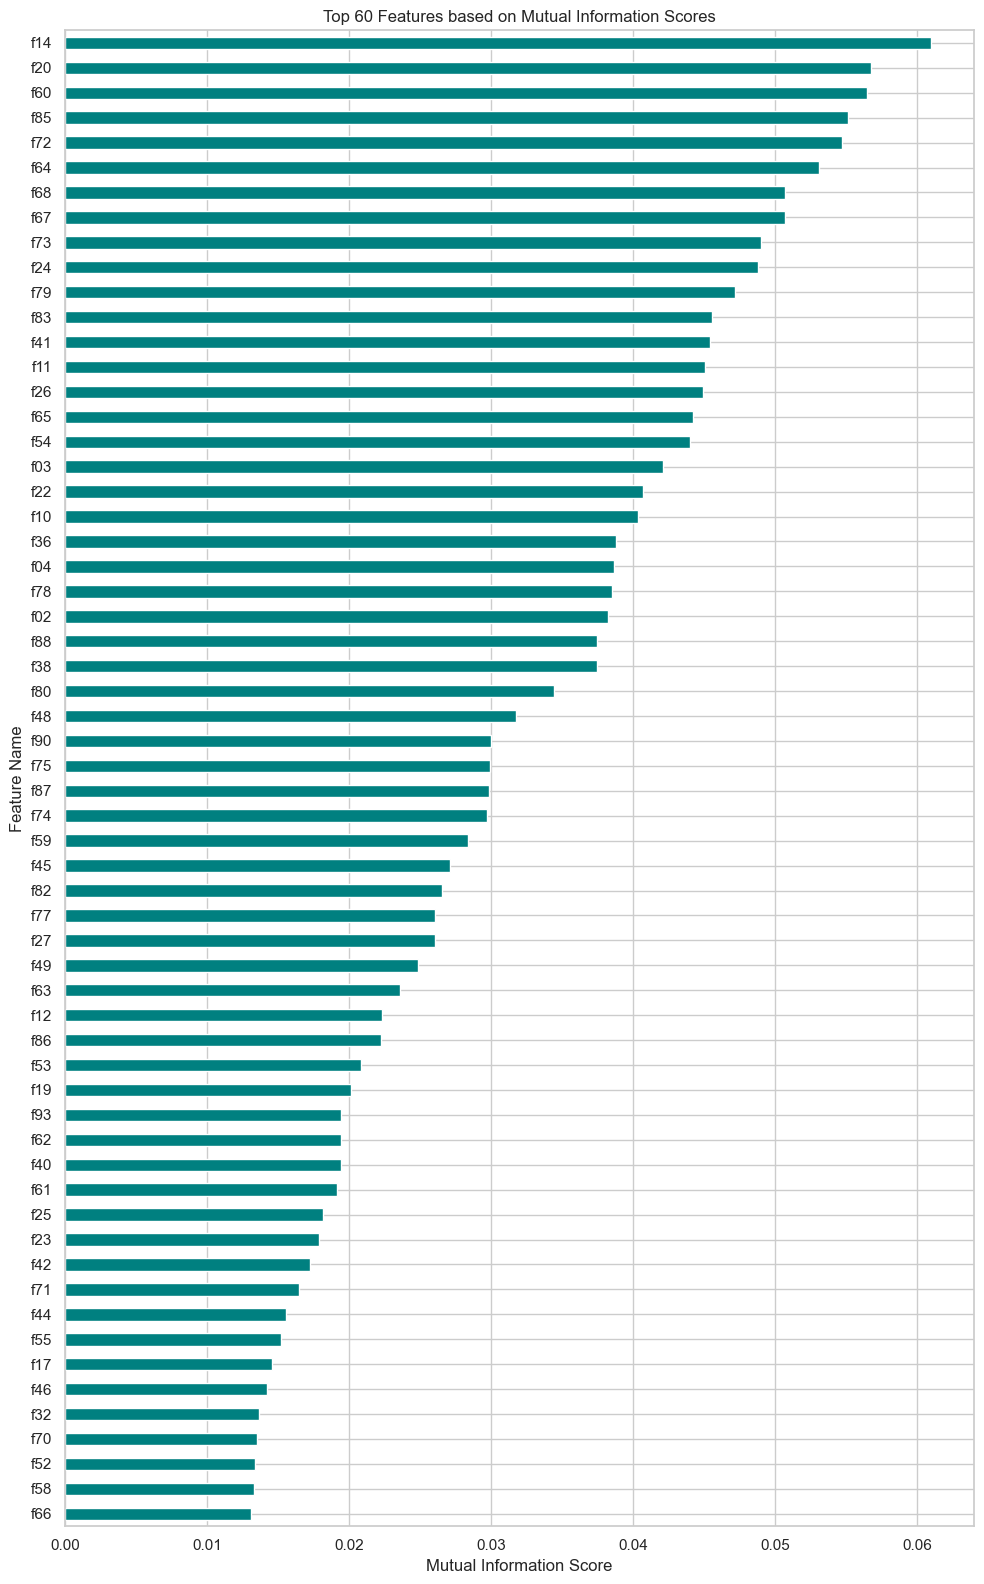

In [ ]:
print("--- Feature Selection using Mutual Information ---")

# 1. Calculate Mutual Information scores using ONLY the training data
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

mi_scores_series = pd.Series(mi_scores, index=X_train.columns)
mi_scores_series = mi_scores_series.sort_values(ascending=False)

# 2. Visualize the Top 60 features with the highest MI scores
plt.figure(figsize=(10, 16))
mi_scores_series.head(60).sort_values().plot(kind='barh', color='teal')
plt.title('Top 60 Features based on Mutual Information Scores')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()


In [10]:
# 3. Select the Top K features
selector = SelectKBest(mutual_info_classif, k=TOP_K_FEATURES)

# Fit the selector on training data and transform BOTH train and validation sets
X_train_selected = selector.fit_transform(X_train, y_train)
X_val_selected = selector.transform(X_val)

# Get the names of the selected features
selected_feature_names = X_train.columns[selector.get_support()]
print(selected_feature_names)

# Convert the NumPy arrays back to Pandas DataFrames to maintain column names
X_train = pd.DataFrame(X_train_selected, columns=selected_feature_names, index=X_train.index)
X_val = pd.DataFrame(X_val_selected, columns=selected_feature_names, index=X_val.index)

print(f"\n--- Selection Summary ---")
print(f"Original number of features: {len(mi_scores_series)}")
print(f"Number of selected features: {TOP_K_FEATURES}")
print(f"Shape of X_train after selection: {X_train.shape}")
print(f"Shape of X_val after selection: {X_val.shape}")

/home/joanna/miniforge3/envs/hw2/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Index(['f02', 'f03', 'f04', 'f10', 'f11', 'f12', 'f14', 'f20', 'f22', 'f24',
       'f26', 'f27', 'f36', 'f38', 'f41', 'f45', 'f48', 'f49', 'f54', 'f59',
       'f60', 'f63', 'f64', 'f65', 'f67', 'f68', 'f72', 'f73', 'f74', 'f75',
       'f77', 'f78', 'f79', 'f80', 'f82', 'f83', 'f85', 'f87', 'f88', 'f90'],
      dtype='object')

--- Selection Summary ---
Original number of features: 95
Number of selected features: 40
Shape of X_train after selection: (4434, 40)
Shape of X_val after selection: (1109, 40)


## Normalization

In [ ]:
print("--- 1. Normalization (Standardization) ---")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)

print(f"X_train shape after scaling: {X_train_scaled.shape}")
print(f"Original class distribution in y_train:\n{y_train.shape}\n")

--- 1. Normalization (Standardization) ---
X_train shape after scaling: (4434, 40)
Original class distribution in y_train:
(4434, 1)



## PCA

In [12]:
print("--- Generating PCA Auxiliary Features ---")

n_components = 5
pca = PCA(n_components=n_components, random_state=42)

pca_train = pca.fit_transform(X_train_scaled)
pca_val = pca.transform(X_val_scaled)

pca_cols = [f'PCA_Comp_{i+1}' for i in range(n_components)]
X_train_pca_df = pd.DataFrame(pca_train, columns=pca_cols, index=X_train_scaled.index)
X_val_pca_df = pd.DataFrame(pca_val, columns=pca_cols, index=X_val_scaled.index)

X_train_combined = pd.concat([X_train_scaled, X_train_pca_df], axis=1)
X_val_combined = pd.concat([X_val_scaled, X_val_pca_df], axis=1)

print(f"Original feature count: {X_train_scaled.shape[1]}")
print(f"Added PCA features: {n_components}")
print(f"New feature count: {X_train_combined.shape[1]}")

X_train_scaled = X_train_combined
X_val_scaled = X_val_combined

print(f"\nTotal variance explained by {n_components} components: {pca.explained_variance_ratio_.sum():.4f}")

--- Generating PCA Auxiliary Features ---
Original feature count: 40
Added PCA features: 5
New feature count: 45

Total variance explained by 5 components: 0.6256


In [ ]:
# print("--- Handle Class Imbalance with SMOTE ---")
# # Initialize SMOTE
# smote = SMOTE(random_state=42)

# X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# print(f"X_train shape after SMOTE: {X_train_resampled.shape}")
# print(f"New class distribution in y_train_resampled (Balanced):\n{y_train_resampled.shape}")

print("--- Handle Class Imbalance with Advanced SMOTE ---")

over1 = BorderlineSMOTE(random_state=42, sampling_strategy=0.3, k_neighbors=8, kind='borderline-1')
over2 = BorderlineSMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=8, kind='borderline-1')
# over1 = BorderlineSMOTE(random_state=42, sampling_strategy='auto', k_neighbors=8, kind='borderline-1')
# under = EditedNearestNeighbours(sampling_strategy="auto", n_neighbors=2)    # bad
steps = [('o1', over1), ('o2', over2)]
# steps = [('o1', over1), ('u1', under)]
smote = ImbPipeline(steps=steps)

# smote = SVMSMOTE(random_state=42)

# smote = KMeansSMOTE(random_state=42, cluster_balance_threshold=0.05)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"X_train shape after Advanced SMOTE: {X_train_resampled.shape}")
print(f"New class distribution:\n{y_train_resampled.shape}")

--- Handle Class Imbalance with Advanced SMOTE ---
X_train shape after Advanced SMOTE: (6334, 45)
New class distribution:
(6334,)


In [14]:
# print("--- 1. Cumulative Mutual Information Visualization ---")

# # Assuming 'mi_scores_series' from Block 6 is already calculated and sorted descending
# # Calculate the cumulative sum of the MI scores
# cumulative_mi = np.cumsum(mi_scores_series)

# # Normalize to a 0.0 - 1.0 scale (0% to 100%)
# cumulative_mi_normalized = cumulative_mi / cumulative_mi.max()

# # Plot the cumulative importance curve
# plt.figure(figsize=(10, 6))
# plt.plot(range(1, len(cumulative_mi_normalized) + 1), cumulative_mi_normalized, marker='.', linestyle='-', color='teal')

# # Draw reference lines at 90% and 95% information coverage
# plt.axhline(y=0.90, color='r', linestyle='--', label='90% Information Coverage')
# plt.axhline(y=0.95, color='orange', linestyle='--', label='95% Information Coverage')

# plt.title('Cumulative Feature Importance based on MI Scores')
# plt.xlabel('Number of Features (K)')
# plt.ylabel('Cumulative MI Score (Normalized)')
# plt.legend(loc='lower right')
# plt.grid(True, alpha=0.5)
# plt.tight_layout()
# plt.show()

## Model Training

### Tuning XGBoost

In [ ]:
if tuning_xgb:
    # Suppress warnings to keep the output clean
    warnings.filterwarnings('ignore')

    print("--- Optuna Hyperparameter Optimization for XGBoost ---")

    # 1. Define the Objective Function
    def objective(trial):
        # Step 1.1: Define the hyperparameter search space
        param_grid = {
            # n_estimators: Number of trees. 
            'n_estimators': trial.suggest_int('n_estimators', 300, 1200, step=100),
            
            # learning_rate: Use log=True to search uniformly in logarithmic space (e.g., 0.01 to 0.1)
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            
            # Tree complexity parameters
            'max_depth': trial.suggest_int('max_depth', 4, 8),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
            'gamma': trial.suggest_float('gamma', 0.0, 0.5),
            
            # Random sampling to prevent overfitting
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            
            # Fixed parameters
            'random_state': 42,
            'eval_metric': 'logloss'
        }
        
        # Step 1.2: Initialize and train the model
        # Note: Use the resampled data from your SMOTE block!
        model = XGBClassifier(**param_grid)
        model.fit(X_train_resampled, y_train_resampled)
        
        # Step 1.3: Predict on the validation set and calculate Macro-F1
        # Note: Use the scaled validation data
        preds = model.predict(X_val_scaled)
        macro_f1 = f1_score(y_val, preds, average='macro')
        
        # Return the metric we want to maximize
        return macro_f1

    # 2. Create an Optuna Study
    # We want to MAXIMIZE the Macro-F1 score
    study = optuna.create_study(direction='maximize', study_name="XGBoost_Optimization")

    # 3. Start the optimization process
    # n_trials: Number of parameter combinations to try (e.g., 30 or 50 is a good start)
    print("Starting optimization... This might take a few minutes.")
    study.optimize(objective, n_trials=100)

    # 4. Output the best results
    print("\n--- Optimization Finished ---")
    print(f"Best Validation Macro-F1 Score: {study.best_value:.4f}")
    print("Best Parameters Found:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")

    # ==========================================
    # 5. Train the Final Best Model
    # ==========================================
    print("\nTraining final XGBoost model with best parameters...")
    xgb_model = XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss')
    xgb_model.fit(X_train_resampled, y_train_resampled)

#### Tuning CatBoost

In [16]:
if tuning_catboost:
    warnings.filterwarnings('ignore')

    print("--- Optuna Hyperparameter Optimization for CatBoost ---")

    def objective(trial):
        param_grid = {
            'iterations': trial.suggest_int('iterations', 500, 2000, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 10),
            'early_stopping_rounds': 50,
            'eval_metric': 'Logloss',
            'random_seed': 42,
            'verbose': 0
        }
        
        model = CatBoostClassifier(**param_grid)
        
        model.fit(
            X_train_resampled, 
            y_train_resampled,
            eval_set=(X_val_scaled, y_val)
        )
        
        preds = model.predict(X_val_scaled)
        macro_f1 = f1_score(y_val, preds, average='macro')
        
        return macro_f1

    study_cat = optuna.create_study(direction='maximize', study_name="CatBoost_Optimization")

    print("Starting optimization for CatBoost... This might take a few minutes.")
    study_cat.optimize(objective, n_trials=100)

    print("\n--- Optimization Finished ---")
    print(f"Best Validation Macro-F1 Score: {study_cat.best_value:.4f}")
    print("Best Parameters Found:")
    for key, value in study_cat.best_params.items():
        print(f"  {key}: {value}")

    print("\nTraining final CatBoost model with best parameters...")

    best_params = study_cat.best_params.copy()
    best_params['early_stopping_rounds'] = 50
    best_params['eval_metric'] = 'Logloss'
    best_params['random_seed'] = 42
    best_params['verbose'] = 0  

    cat_model = CatBoostClassifier(**best_params)

    # Train the final model with the best parameters
    cat_model.fit(
        X_train_resampled, 
        y_train_resampled,
        eval_set=(X_val_scaled, y_val)
    )
    print("Final CatBoost model is ready for testing!")

#### Tuning LightGBM

In [ ]:
if tuning_lgbm:
    warnings.filterwarnings('ignore')

    print("--- Optuna Hyperparameter Optimization for LightGBM ---")

    def objective(trial):
        param_grid = {
            'n_estimators': trial.suggest_int('n_estimators', 500, 2000, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            
            'num_leaves': trial.suggest_int('num_leaves', 15, 63),
            'max_depth': trial.suggest_int('max_depth', 4, 8),
            'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
            
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True), 
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True), 
            
            'random_state': 42,
            'n_jobs': -1,
            'verbose': -1
        }
        
        model = LGBMClassifier(**param_grid)
        
        callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False)]
        
        model.fit(
            X_train_resampled, 
            y_train_resampled,
            eval_set=[(X_val_scaled, y_val)],
            callbacks=callbacks
        )
        
        preds = model.predict(X_val_scaled)
        macro_f1 = f1_score(y_val, preds, average='macro')
        
        return macro_f1

    study_lgbm = optuna.create_study(direction='maximize', study_name="LightGBM_Optimization")

    print("Starting optimization for LightGBM... This is usually very fast!")
    study_lgbm.optimize(objective, n_trials=100)

    print("\n--- Optimization Finished ---")
    print(f"Best Validation Macro-F1 Score: {study_lgbm.best_value:.4f}")
    print("Best Parameters Found:")
    for key, value in study_lgbm.best_params.items():
        print(f"  {key}: {value}")


    print("\nTraining final LightGBM model with best parameters...")

    best_params = study_lgbm.best_params.copy()
    best_params['random_state'] = 42
    best_params['n_jobs'] = -1
    best_params['verbose'] = -1
    lgbm_model = LGBMClassifier(**best_params)

    lgbm_model.fit(
        X_train_resampled, 
        y_train_resampled,
        eval_set=[(X_val_scaled, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    print("Final LightGBM model is ready for testing!")

In [18]:
cat_params = {
    'iterations': 1200,                         
    'learning_rate': 0.18889726659196712,
    'depth': 8,                                 
    'l2_leaf_reg': 7,                   
    'early_stopping_rounds': 100,
    'random_state': 42,
    'eval_metric': 'Logloss',
    'verbose': 0         
}
# cat_params = {
#     'iterations': 1600,                         
#     'learning_rate': 0.03270868259201957,
#     'depth': 10,                                 
#     'l2_leaf_reg': 8,                   
#     'early_stopping_rounds': 100,
#     'random_state': 42,
#     'eval_metric': 'Logloss',
#     'verbose': 0         
# }

xgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.07697309570362153,
    'max_depth': 8,
    'min_child_weight': 3,
    'gamma': 0.13649902509305026,
    'subsample': 0.6550289619990084,
    'colsample_bytree': 0.9948020339480929,
    'random_state': 42,
    'eval_metric': 'logloss',
    # 'verbose': 0
}

lgbm_params = {
  'n_estimators': 1900,
  'learning_rate': 0.05223844993903318,
  'num_leaves': 26,
  'max_depth': 4,
  'min_child_samples': 64,
  'subsample': 0.9409882655993758,
  'colsample_bytree': 0.7696347502921173,
  'reg_alpha': 0.09682726508750379,
  'reg_lambda': 0.0014810875290240395,
  'random_state': 42,
  'n_jobs': -1,
  'verbose': -1
}

cat_model = CatBoostClassifier(**cat_params)
xgb_model = XGBClassifier(**xgb_params)
lgbm_model = LGBMClassifier(**lgbm_params)

# cat_model.fit(X_train_resampled, y_train_resampled, eval_set=(X_val_scaled, y_val))
# xgb_model.fit(X_train_resampled, y_train_resampled, eval_set=[(X_val_scaled, y_val)])
# lgbm_model.fit(X_train_resampled, y_train_resampled, eval_set=[(X_val_scaled, y_val)], callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])

# # # print the validation performance of the tuned models
# cat_preds = cat_model.predict(X_val_scaled)
# cat_f1 = f1_score(y_val, cat_preds, average='macro')
# print(f"CatBoost Validation Macro-F1 Score: {cat_f1:.4f}")

# xgb_preds = xgb_model.predict(X_val_scaled)
# xgb_f1 = f1_score(y_val, xgb_preds, average='macro')
# print(f"XGBoost Validation Macro-F1 Score: {xgb_f1:.4f}")

# lgbm_preds = lgbm_model.predict(X_val_scaled)
# lgbm_f1 = f1_score(y_val, lgbm_preds, average='macro')
# print(f"LightGBM Validation Macro-F1 Score: {lgbm_f1:.4f}")

#### Model Stacking

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

print("--- Advanced Technique: Model Stacking ---")

estimators = [
    ('xgb', xgb_model),
    ('lgbm', lgbm_model),
    ('cat', cat_model)
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5, 
    n_jobs=-1
)

stacking_clf.fit(X_train_resampled, y_train_resampled)

stack_preds = stacking_clf.predict(X_val_scaled)
stack_macro_f1 = f1_score(y_val, stack_preds, average='macro')
print(f"Stacking Classifier Macro-F1: {stack_macro_f1:.4f}")

--- Advanced Technique: Model Stacking ---
Stacking Classifier Macro-F1: 0.7545


In [ ]:
print("--- Advanced Technique: Threshold Optimization ---")

# model = cat_model
# model = xgb_model
# model = lgbm_model
model = stacking_clf

y_val_probs = model.predict_proba(X_val_scaled)[:, 1]

best_threshold = 0.5
best_f1 = 0.0

thresholds = np.arange(0.1, 0.9, 0.01)

for threshold in thresholds:
    adjusted_preds = (y_val_probs >= threshold).astype(int)
    current_f1 = f1_score(y_val, adjusted_preds, average='macro')
    
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

print(f"Default (0.5) Macro-F1: {f1_score(y_val, model.predict(X_val_scaled), average='macro'):.4f}")
print(f"Optimized ({best_threshold:.2f}) Macro-F1: {best_f1:.4f}")


--- Advanced Technique: Threshold Optimization ---
Default (0.5) Macro-F1: 0.7545
Optimized (0.12) Macro-F1: 0.7829


## Predict the results

In [22]:
print("--- Testing Data Processing ---")
print(f"Original test set shape: {test_df.shape}")
print(f"Missing values in test set before processing:\n{test_df.isnull().sum()}")

--- Testing Data Processing ---
Original test set shape: (1386, 95)
Missing values in test set before processing:
f01    126
f02    129
f03    131
f04    148
f05    149
      ... 
f91    129
f92    145
f93    151
f94    153
f95    129
Length: 95, dtype: int64


In [23]:
# 2. Preprocessing: Handle missing values in test set
test_processed = test_df.copy()

# Separate features from Id (Testing data usually doesn't have the 'Bankrupt' target)
if 'Id' in test_df.columns:
    X_test = test_df.drop(columns=['Id'])
else:
    X_test = test_df.copy()

# ==========================================
# 2. Imputation: Fill missing values
# IMPORTANT: Use the 'imputer' fitted on the Training Set!
# Do NOT call fit() or fit_transform() here.
# ==========================================
print("Applying IterativeImputer to test set...")
X_test_imputed = imputer.transform(X_test)

# Convert back to DataFrame (Ensure column names are preserved)
# Note: If add_indicator=True was used, the number of columns will be larger than the original
if hasattr(imputer, 'get_feature_names_out'):
    # For newer sklearn versions that support get_feature_names_out on IterativeImputer
    imputed_cols = imputer.get_feature_names_out(X_test.columns)
else:
    # Fallback: if indicators were added, we just use a generic range for new columns or carefully map them
    # Assuming add_indicator=False or handling it normally:
    imputed_cols = X_test.columns # Change this if add_indicator generated new columns

X_test_imputed_df = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

# ==========================================
# 3. Feature Selection
# IMPORTANT: Use the 'selector' fitted on the Training Set!
# ==========================================
print("Applying Feature Selection to test set...")
X_test_selected = selector.transform(X_test_imputed_df)
X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_feature_names, index=X_test.index)

# ==========================================
# 4. Normalization (Scaling)
# IMPORTANT: Use the 'scaler' fitted on the Training Set!
# ==========================================
print("Applying StandardScaler to test set...")
X_test_scaled = scaler.transform(X_test_selected_df)

# 5. PCA Auxiliary Features
print("Generating PCA features for test set...")
pca_test = pca.transform(X_test_scaled)
X_test_pca_df = pd.DataFrame(pca_test, columns=pca_cols, index=X_test.index)
X_test_final = pd.concat([pd.DataFrame(X_test_scaled, columns=X_test_selected_df.columns, index=X_test.index), X_test_pca_df], axis=1)


Applying IterativeImputer to test set...
[IterativeImputer] Completing matrix with shape (1386, 95)
[IterativeImputer] Ending imputation round 1/5, elapsed time 0.01
[IterativeImputer] Ending imputation round 2/5, elapsed time 0.03
[IterativeImputer] Ending imputation round 3/5, elapsed time 0.04
[IterativeImputer] Ending imputation round 4/5, elapsed time 0.05
[IterativeImputer] Ending imputation round 5/5, elapsed time 0.06
Applying Feature Selection to test set...
Applying StandardScaler to test set...
Generating PCA features for test set...


/home/joanna/miniforge3/envs/hw2/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


In [ ]:
# 4. Generate Predictions

# predictions = model.predict(X_test_scaled)

test_probs = model.predict_proba(X_test_final)[:, 1]
predictions = (test_probs >= best_threshold).astype(int)

# 5. Create the submission DataFrame
if 'Id' in test_df.columns:
    submission_ids = test_df['Id']
else:
    submission_ids = range(0, len(test_df))

submission = pd.DataFrame({
    'Id': submission_ids,
    'Bankrupt': predictions
})

# 6. Export to CSV
submission.to_csv(output_name, index=False)

print("\n--- Submission File Ready ---")
print(f"File saved as: {output_name}")
print(f"Number of rows: {len(submission)}")
display(submission.head())


--- Submission File Ready ---
File saved as: result/out_0415_43.csv
Number of rows: 1386


,Id,Bankrupt
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
